# `Sigma_prj(R | lob, zob)` audit — visual tour

Self-contained notebook. Loads the pre-computed artifacts in `validations/cache/` and plots every tabulated quantity. No heavy computation here.

Reference point throughout: `(lob, zob) = (20, 0.5)` unless noted. The 12 DES-Y3 bin centres are 4 richness means `[25, 37.5, 52.5, 130]` × 3 redshift means `[0.275, 0.425, 0.575]`.

**Sections**

1. Angular scales per bin — `theta_lambda`, `2·theta_lambda`, `theta_R(R=30)`.
2. Is the Delta-chi-only approximation safe? (spoiler: no.)
3. Centerpiece — the z-integrand `W(z)` and the theta-integrand `N_theta(theta) · Sigma_mis`, including the RND vs cl+LSS split.
4. z-axis symmetry study.
5. `theta_max_mode` sensitivity across the 12 bins.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.25})

CACHE = os.path.abspath(os.path.join(os.getcwd(), '..', 'validations', 'cache'))
assert os.path.isdir(CACHE), f'cache directory missing: {CACHE}'
print('cache dir:', CACHE)
for f in sorted(os.listdir(CACHE)):
    print(f'  {f}  ({os.path.getsize(os.path.join(CACHE, f))/1024:.1f} kB)')

cache dir: /Users/esteves/Documents/github/RichnessSelection/validations/cache
  dchi_only_error.csv  (5.5 kB)
  ntheta_per_R.npz  (24.1 kB)
  sigma_prj_rnd_cl.npz  (9.1 kB)
  theta_lambda_12bins.csv  (2.4 kB)
  theta_max_compare.csv  (14.9 kB)
  xi_weights_z.npz  (339.2 kB)
  z_symmetry.csv  (3.0 kB)


## 1. Angular scales across the 12 Y3 bins

Three scales compete for the θ integration support:

- `theta_lambda = R_lambda(lam) (1+z) / chi(z)` — angular radius of the *aperture-overlap kernel* `f_A` (folded into `b_sel`).
- `2·theta_lambda` — where `f_A` support ends.
- `theta_R = R / D_A(z_ob)` — angular location of the `Sigma_mis` peak at a given R. This moves with R.

The key question — *can θ integration be truncated at 2·theta_lambda?* — comes down to whether `theta_R` stays inside or outside that window. At R = 30 cMpc/h, `theta_R` is 14–20× larger than `2·theta_lambda`, so truncating would chop out most of the NFW support. This is the physics reason the `theta_max_mode="30_Mpc"` default was chosen.

In [2]:
df_tl = pd.read_csv(os.path.join(CACHE, 'theta_lambda_12bins.csv'))
df_tl.round({
    'R_lambda_cMpch': 3, 'chi_cMpch': 1, 'D_A_cMpch': 1,
    'theta_lambda_arcmin': 3, 'two_theta_lambda_arcmin': 3,
    'ratio_thetaR30_over_2thetalam': 1,
})

,lam_bar,z_bar,R_lambda_cMpch,chi_cMpch,D_A_cMpch,theta_lambda_rad,theta_lambda_arcmin,two_theta_lambda_rad,two_theta_lambda_arcmin,theta_R_at_30Mpch_rad,ratio_thetaR30_over_2thetalam
0,25.0,0.275,0.758,773.5,606.7,0.001249,4.294,0.002498,8.589,0.049450,19.8
1,25.0,0.425,0.758,1151.2,807.9,0.000938,3.225,0.001876,6.450,0.037134,19.8
2,25.0,0.575,0.758,1498.3,951.3,0.000797,2.739,0.001593,5.477,0.031535,19.8
3,37.5,0.275,0.822,773.5,606.7,0.001355,4.657,0.002709,9.314,0.049450,18.3
4,37.5,0.425,0.822,1151.2,807.9,0.001017,3.497,0.002035,6.995,0.037134,18.3
5,37.5,0.575,0.822,1498.3,951.3,0.000864,2.970,0.001728,5.940,0.031535,18.3
6,52.5,0.275,0.879,773.5,606.7,0.001449,4.981,0.002898,9.963,0.049450,17.1
7,52.5,0.425,0.879,1151.2,807.9,0.001088,3.741,0.002176,7.482,0.037134,17.1
8,52.5,0.575,0.879,1498.3,951.3,0.000924,3.177,0.001848,6.353,0.031535,17.1
9,130.0,0.275,1.054,773.5,606.7,0.001737,5.972,0.003474,11.944,0.049450,14.2


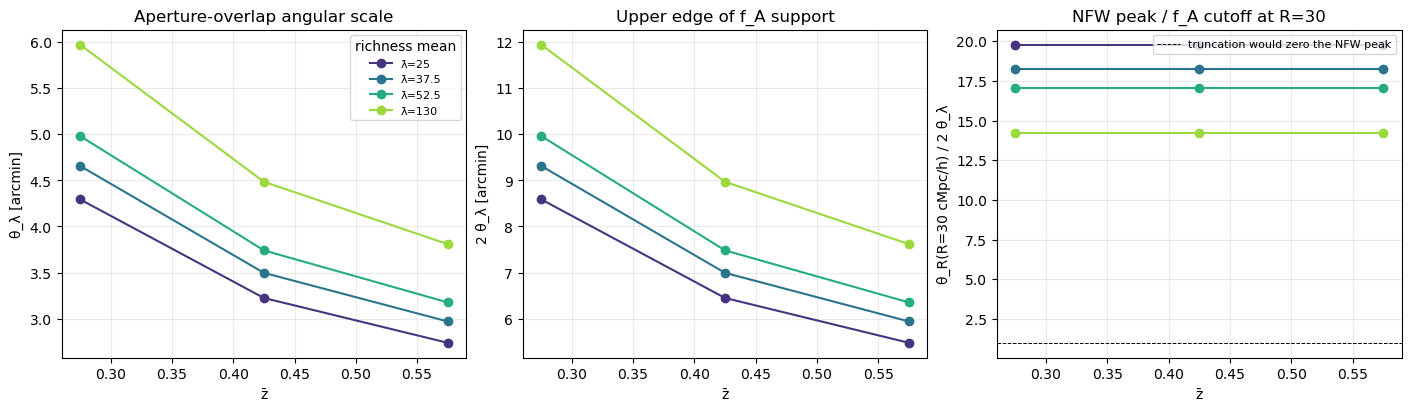

In [3]:
# Three panels: theta_lambda vs z (lines = lam), 2 theta_lambda / arcmin,
# and the ratio theta_R(R=30) / 2 theta_lambda.
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
lam_means = sorted(df_tl['lam_bar'].unique())
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(lam_means)))

for lam, col in zip(lam_means, colors):
    sub = df_tl[df_tl['lam_bar'] == lam].sort_values('z_bar')
    axes[0].plot(sub['z_bar'], sub['theta_lambda_arcmin'],
                 marker='o', color=col, label=f'λ̄={lam:g}')
    axes[1].plot(sub['z_bar'], sub['two_theta_lambda_arcmin'],
                 marker='o', color=col)
    axes[2].plot(sub['z_bar'], sub['ratio_thetaR30_over_2thetalam'],
                 marker='o', color=col)

axes[0].set(xlabel='z̄', ylabel='θ_λ [arcmin]',
            title='Aperture-overlap angular scale')
axes[0].legend(fontsize=8, title='richness mean')
axes[1].set(xlabel='z̄', ylabel='2 θ_λ [arcmin]',
            title='Upper edge of f_A support')
axes[2].set(xlabel='z̄', ylabel='θ_R(R=30 cMpc/h) / 2 θ_λ',
            title='NFW peak / f_A cutoff at R=30')
axes[2].axhline(1.0, color='k', ls='--', lw=0.7,
                 label='truncation would zero the NFW peak')
axes[2].legend(fontsize=8, loc='upper right')
plt.show()

## 2. Is the Delta-chi-only approximation safe?

The exact separation is
```
|Dr|^2 = chi(z)^2 + chi(z_ob)^2 - 2 chi(z) chi(z_ob) cos(theta)
       ~ (chi(z) - chi(z_ob))^2 + chi^2 theta^2   (small-angle)
```
Dropping the `chi^2 theta^2` term would decouple the z and θ integrals — attractive for speed. But near the ring (`|Delta chi| -> 0`) this term dominates, so `xi_NL(|Dr|)` gets evaluated at the wrong r.

`sigma_prj_dchi_only.py` computed `int dz dV w_z xi_NL(|Dr|)` with the exact and the Delta-chi-only forms, at θ ∈ {0.1, 0.5, 1, 2} · θ_λ across the 12 bins.

**Summary table** (below): max and median absolute relative error across the 12 bins at each θ value.

In [4]:
df_dchi = pd.read_csv(os.path.join(CACHE, 'dchi_only_error.csv'))
summary = (df_dchi.assign(abs_err=lambda d: np.abs(d['rel_error']))
            .groupby('theta_frac_of_lam')['abs_err']
            .agg(['median', 'max'])
            .rename(columns={'median': 'median |rel_err|',
                             'max': 'max |rel_err|'}))
summary

,median |rel_err|,max |rel_err|
theta_frac_of_lam,,
0.1,0.374542,0.446792
0.5,2.861813,3.579179
1.0,6.179768,7.205778
2.0,11.458185,13.063738


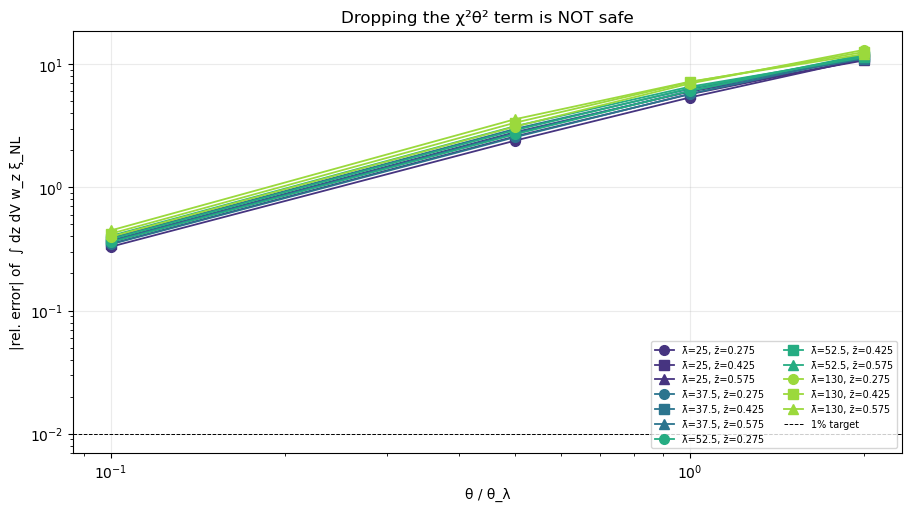

Even at θ = 0.1 θ_λ the worst-bin error is already 45%.
At θ = 2 θ_λ the error is > 1000%. The approximation is not usable.


In [5]:
# Per-bin absolute relative error vs theta/theta_lambda, coloured by lam,
# one line per (lam, z). Log y-axis.
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
lam_means = sorted(df_dchi['lam_bar'].unique())
z_means = sorted(df_dchi['z_bar'].unique())
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(lam_means)))
markers = ['o', 's', '^']

for lam, col in zip(lam_means, colors):
    for zbar, mk in zip(z_means, markers):
        sub = df_dchi[(df_dchi['lam_bar'] == lam) &
                       (df_dchi['z_bar'] == zbar)].sort_values('theta_frac_of_lam')
        ax.plot(sub['theta_frac_of_lam'], np.abs(sub['rel_error']),
                 marker=mk, color=col, lw=1.3, ms=7,
                 label=f'λ̄={lam:g}, z̄={zbar:g}')
ax.set(xscale='log', yscale='log',
        xlabel='θ / θ_λ', ylabel='|rel. error| of  ∫ dz dV w_z ξ_NL',
        title='Dropping the χ²θ² term is NOT safe')
ax.axhline(0.01, color='k', ls='--', lw=0.7, label='1% target')
ax.legend(fontsize=7, ncol=2, loc='lower right')
plt.show()
print('Even at θ = 0.1 θ_λ the worst-bin error is already 45%.')
print('At θ = 2 θ_λ the error is > 1000%. The approximation is not usable.')

## 3a. The z-integrand `W(z)` across the 12 bins

The z-axis integrand inside `Sigma_prj` is
```
W(z) = dV(z)/dz dΩ · w_z(z, z_ob) · n̄(M̄, z) · ξ_NL(|Delta chi|, z_ob)
```
where the LoS-slab exclusion `|Delta chi| < R_excl` is masked out (as per the `P1/I1/I2` convention).

`xi_NL(|Delta chi|)` is **exactly symmetric** around z_ob (it is a function of `|z - z_ob|`). The asymmetry comes from `dV(z) ∝ chi²/H(z)` — rising fast at low z. The two red curves below (raw `xi` and exclusion-masked `xi_excl`) show the symmetry around `Delta z = 0`; the blue curves show how the *full integrand* inherits the `dV` asymmetry most visibly at low `z̄`.

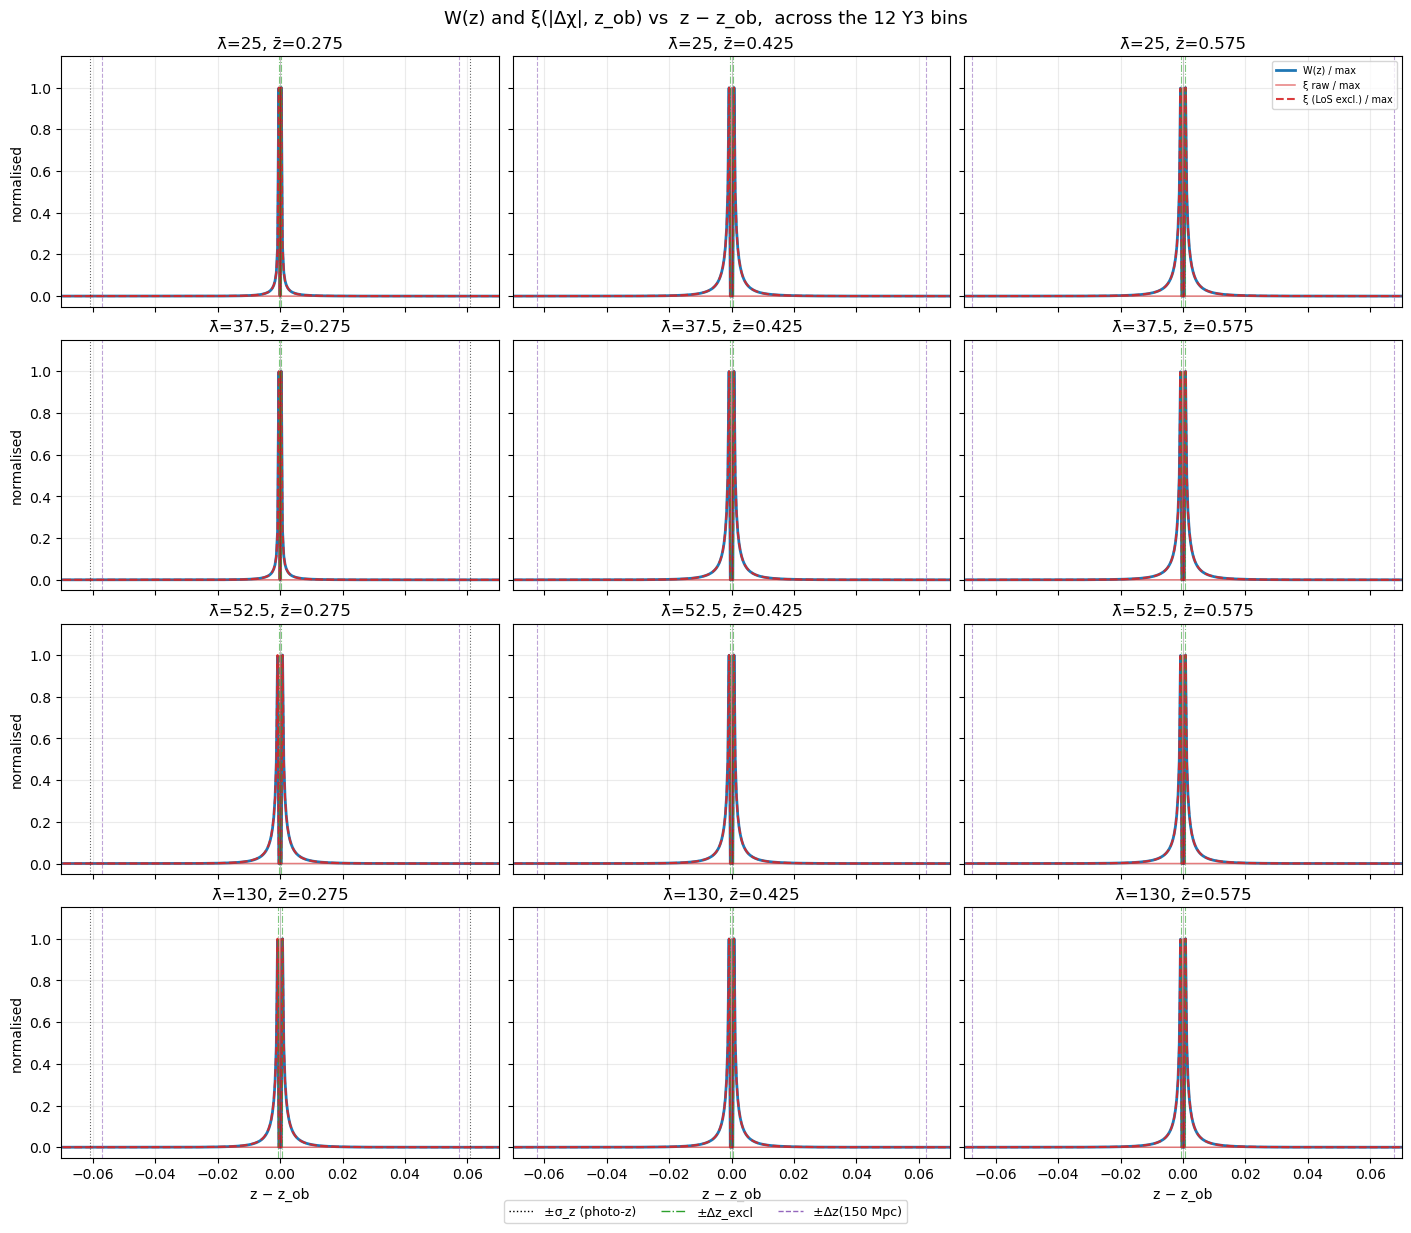

In [6]:
from richness_selection.photoz import sigma_z
from richness_selection.geometry import R_lambda

xi_data = np.load(os.path.join(CACHE, 'xi_weights_z.npz'))
keys = sorted({k.split('__')[0] for k in xi_data.files})
def key_sort(k):
    _, lam, _, z = k.split('_'); return (float(lam), float(z))
keys = sorted(keys, key=key_sort)
lam_means = sorted({float(k.split('_')[1]) for k in keys})
z_means = sorted({float(k.split('_')[3]) for k in keys})

fig, axes = plt.subplots(len(lam_means), len(z_means),
                         figsize=(14, 12), sharex=True, sharey=True,
                         constrained_layout=True)
for i, lam in enumerate(lam_means):
    for j, zbar in enumerate(z_means):
        ax = axes[i, j]
        key = f'lam_{lam:g}_z_{zbar:g}'
        zs = xi_data[f'{key}__zs']; dz = zs - zbar
        W = xi_data[f'{key}__W']; xi_excl = xi_data[f'{key}__xi_excl']
        xi_raw = xi_data[f'{key}__xi']
        ax.plot(dz, W / max(W.max(), 1e-30), color='C0', lw=2.0,
                 label='W(z) / max')
        ax.plot(dz, xi_raw / max(xi_raw.max(), 1e-30),
                 color='C3', lw=1.1, alpha=0.6, label='ξ raw / max')
        ax.plot(dz, xi_excl / max(xi_excl.max(), 1e-30),
                 color='C3', lw=1.5, ls='--', alpha=0.9,
                 label='ξ (LoS excl.) / max')
        # Scale markers
        sig = float(sigma_z(zbar))
        R_excl = float(R_lambda(lam)) * (1.0 + zbar)
        # dchi/dz local estimate
        from richness_selection import Cosmology
        cosmo = Cosmology(); dchi_dz = float((cosmo.chi(zbar + 1e-3)
                                              - cosmo.chi(zbar - 1e-3)) / 2e-3)
        dz_excl = R_excl / dchi_dz
        dz_150 = 150.0 / dchi_dz
        for v, ls, col in [(sig, ':', 'k'),
                           (dz_excl, '-.', 'C2'),
                           (dz_150, '--', 'C4')]:
            ax.axvline(+v, ls=ls, color=col, alpha=0.6, lw=0.8)
            ax.axvline(-v, ls=ls, color=col, alpha=0.6, lw=0.8)
        ax.axvline(0, color='k', lw=0.4, alpha=0.3)
        ax.set(title=f'λ̄={lam:g}, z̄={zbar:g}', xlim=(-0.07, 0.07),
                ylim=(-0.05, 1.15))
        if i == len(lam_means) - 1:
            ax.set_xlabel('z − z_ob')
        if j == 0:
            ax.set_ylabel('normalised')
        if i == 0 and j == len(z_means) - 1:
            ax.legend(fontsize=7, loc='upper right')

# Shared marker legend
legend_lines = [plt.Line2D([0], [0], color='k', ls=':', lw=1, label='±σ_z (photo-z)'),
                plt.Line2D([0], [0], color='C2', ls='-.', lw=1, label='±Δz_excl'),
                plt.Line2D([0], [0], color='C4', ls='--', lw=1, label='±Δz(150 Mpc)')]
fig.legend(handles=legend_lines, loc='lower center',
            ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=9)
fig.suptitle('W(z) and ξ(|Δχ|, z_ob) vs  z − z_ob,  across the 12 Y3 bins',
              fontsize=13)
plt.show()

## 3b. The θ-integrand at `(lob, zob) = (20, 0.5)`

Three views, all at the fixed reference point, for R ∈ {0.3, 1, 3, 10} cMpc/h:

1. **`N_theta(theta)`** — the θ-differential (no Sigma_mis): mostly monotone in θ because `sin(theta)` grows, with a kink near `theta_excl,o` where the LoS mask kicks in.
2. **`Sigma_mis(R, R_mis=theta · D_A)` per R** — the 2D NFW lookup seen from above, its shape in θ.
3. **Full integrand `N_theta(theta) · Sigma_mis(R, θ D_A)`** — the product that is numerically integrated. Each R peaks sharply *at* `theta_R = R / D_A(z_ob)`; that is why θ must be the outer loop and the grid must have breakpoints at each `theta_R`.

Vertical markers: `theta_excl,o` (green `-.`), `theta_lambda` (orange `--`), `2 theta_lambda` (orange `:`), and per-R `theta_R` in the curve's own colour.

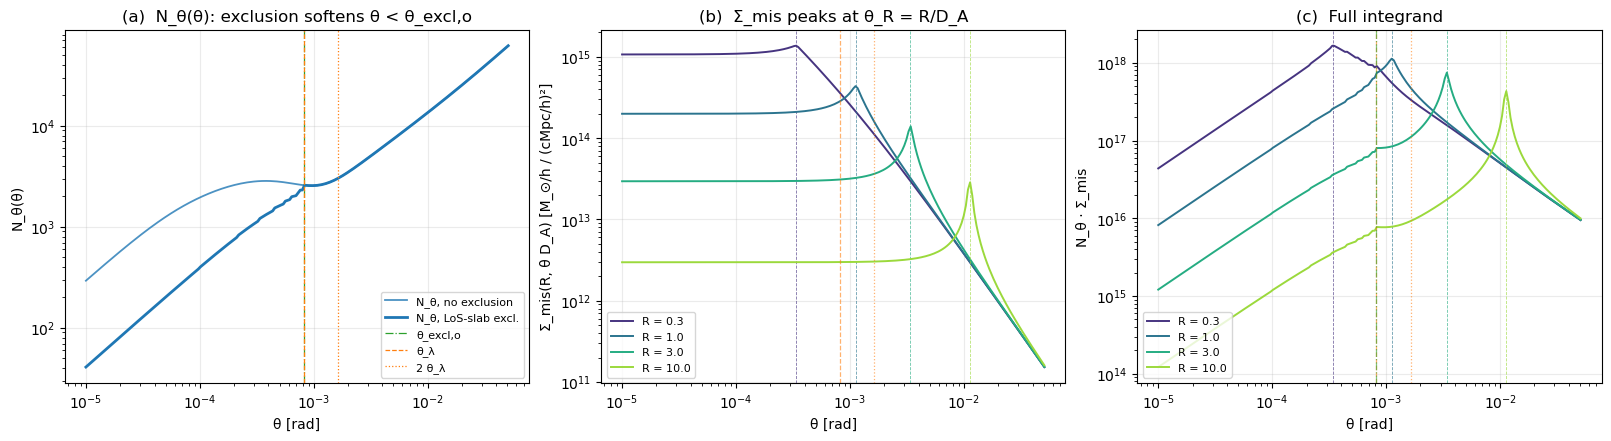

In [7]:
nth = np.load(os.path.join(CACHE, 'ntheta_per_R.npz'))
thetas = nth['thetas']
R_vals = nth['R_vals']; theta_R = nth['theta_R']
theta_lob = float(nth['theta_lob'])
theta_excl_ob = float(nth['theta_excl_ob'])
Ntheta_excl = nth['N_theta_excl']
Ntheta_noexcl = nth['N_theta_noexcl']
S_mis = nth['Sigma_mis']            # (NR, Ntheta)
integrand = nth['integrand']        # (NR, Ntheta)
R_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(R_vals)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), constrained_layout=True)

# Panel 1: N_theta(theta) with and without exclusion
ax = axes[0]
ax.loglog(thetas, Ntheta_noexcl, color='C0', lw=1.3, alpha=0.8,
           label='N_θ, no exclusion')
ax.loglog(thetas, Ntheta_excl, color='C0', lw=2.0,
           label='N_θ, LoS-slab excl.')
ax.axvline(theta_excl_ob, color='C2', ls='-.', lw=0.9, label='θ_excl,o')
ax.axvline(theta_lob, color='C1', ls='--', lw=0.9, label='θ_λ')
ax.axvline(2 * theta_lob, color='C1', ls=':', lw=0.9, label='2 θ_λ')
ax.set(xlabel='θ [rad]', ylabel='N_θ(θ)',
        title='(a)  N_θ(θ): exclusion softens θ < θ_excl,o')
ax.legend(fontsize=8, loc='lower right')

# Panel 2: Sigma_mis(R, R_mis=theta*D_A) per R
ax = axes[1]
for iR, (R, col, tR) in enumerate(zip(R_vals, R_colors, theta_R)):
    ax.loglog(thetas, S_mis[iR], color=col, lw=1.4, label=f'R = {R:.1f}')
    ax.axvline(tR, color=col, ls='--', lw=0.6, alpha=0.7)
ax.axvline(theta_lob, color='C1', ls='--', lw=0.9, alpha=0.6)
ax.axvline(2 * theta_lob, color='C1', ls=':', lw=0.9, alpha=0.6)
ax.set(xlabel='θ [rad]', ylabel='Σ_mis(R, θ D_A) [M_⊙/h / (cMpc/h)²]',
        title='(b)  Σ_mis peaks at θ_R = R/D_A')
ax.legend(fontsize=8, loc='lower left')

# Panel 3: full integrand
ax = axes[2]
for iR, (R, col, tR) in enumerate(zip(R_vals, R_colors, theta_R)):
    ax.loglog(thetas, integrand[iR], color=col, lw=1.4, label=f'R = {R:.1f}')
    ax.axvline(tR, color=col, ls='--', lw=0.6, alpha=0.7)
ax.axvline(theta_lob, color='C1', ls='--', lw=0.9, alpha=0.6)
ax.axvline(2 * theta_lob, color='C1', ls=':', lw=0.9, alpha=0.6)
ax.axvline(theta_excl_ob, color='C2', ls='-.', lw=0.9, alpha=0.6)
ax.set(xlabel='θ [rad]', ylabel='N_θ · Σ_mis', title='(c)  Full integrand')
ax.legend(fontsize=8, loc='lower left')

plt.show()

### 3b.2  RND vs cl+LSS: which piece dominates where?

Inside `SigmaPrj.__call__(return_decomposition=True)` the θ-integrand decomposes as
```
N_theta(theta) = N_rnd(theta) + N_cl_LSS(theta)

N_rnd(theta)    = 2 pi sin(theta) * int dz dV/dzdΩ w_z(z,zob) * int dM n(M,z)
N_cl_LSS(theta) = 2 pi sin(theta) * b_sel(theta)
                  * int dz dV/dzdΩ w_z(z,zob) * xi_NL(|Δr|, zob) 1[theta > theta_excl(z)]
                  * int dM n(M,z) b(M,z)
```

`N_rnd` is smooth and scales only through `sin(theta)`; `N_cl_LSS` inherits the sharp ring of `xi_NL(|Δχ|)` and the soft sigmoid of `b_sel(theta)`. The question is whether `N_rnd >> N_cl_LSS` everywhere (in which case the clustering term is a cosmetic correction) or whether `N_cl_LSS` wins on small scales.

**Answer (from the cached scan):** neither dominates globally.

- At `θ = θ_λ ≈ 8·10⁻⁴` rad, `N_rnd / N_cl_LSS ≈ 0.64` — `N_cl_LSS` is *bigger*.
- The two cross near `θ ≈ 1.1·10⁻³` rad (just above `θ_λ`).
- Far out at `θ = θ_max`, `N_rnd / N_cl_LSS ≈ 220` — clustering is negligible there.

Takeaway: on scales inside the aperture (where clusters actually live) the clustering term is what matters; the RND piece is the dominant contribution only in the NFW tail.

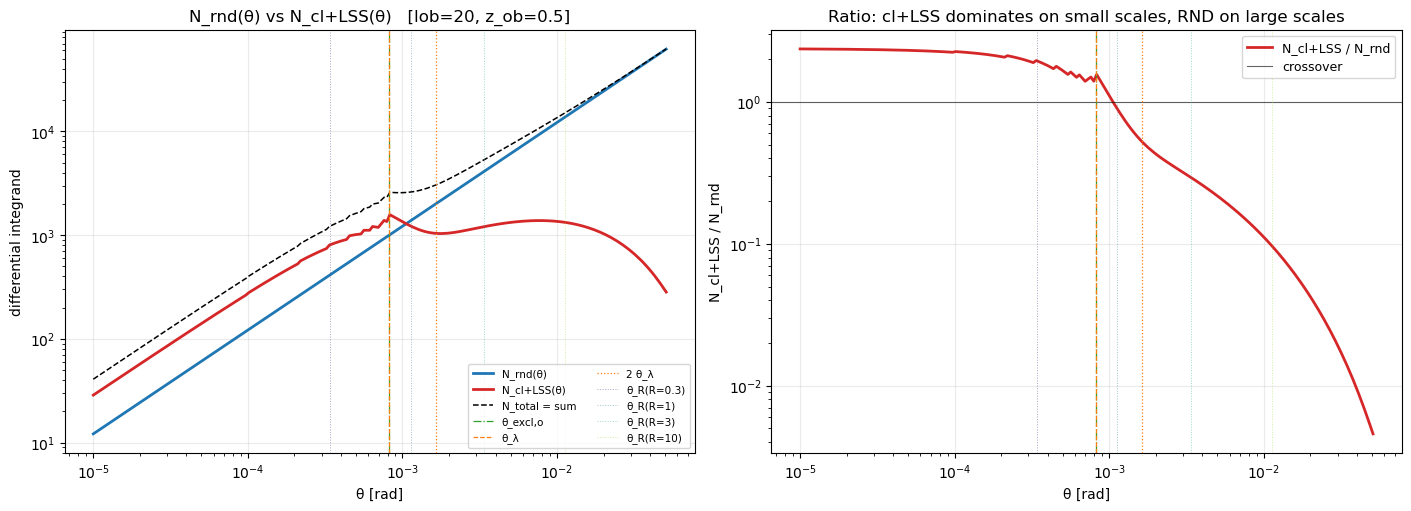


      marker     θ [rad]         N_rnd      N_cl+LSS  N_cl/N_rnd
    θ_excl,o   8.282e-04     1.008e+03     1.574e+03       1.561
         θ_λ   8.282e-04     1.008e+03     1.574e+03       1.561
       2 θ_λ   1.645e-03     2.002e+03     1.039e+03       0.519
  θ_R(R=0.3)   3.366e-04     4.097e+02     8.015e+02       1.956
    θ_R(R=1)   1.118e-03     1.361e+03     1.232e+03       0.905
    θ_R(R=3)   3.410e-03     4.150e+03     1.209e+03       0.291
   θ_R(R=10)   1.133e-02     1.379e+04     1.325e+03       0.096
       θ_max   3.454e-02     4.204e+04     5.813e+02       0.014


In [8]:
N_rnd = nth['N_rnd']
N_cl = nth['N_cl_lss']
bsel = nth['bsel']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Panel 1: N_rnd and N_cl_LSS on the same log-log axis
ax = axes[0]
ax.loglog(thetas, N_rnd, color='C0', lw=2.0, label='N_rnd(θ)')
ax.loglog(thetas, N_cl, color='C3', lw=2.0, label='N_cl+LSS(θ)')
ax.loglog(thetas, N_rnd + N_cl, color='k', lw=1.1, ls='--',
           label='N_total = sum')
ax.axvline(theta_excl_ob, color='C2', ls='-.', lw=0.9, label='θ_excl,o')
ax.axvline(theta_lob, color='C1', ls='--', lw=0.9, label='θ_λ')
ax.axvline(2 * theta_lob, color='C1', ls=':', lw=0.9, label='2 θ_λ')
for iR, (R, col, tR) in enumerate(zip(R_vals, R_colors, theta_R)):
    ax.axvline(tR, color=col, ls=':', lw=0.7, alpha=0.45,
                label=f'θ_R(R={R:g})')
ax.set(xlabel='θ [rad]', ylabel='differential integrand',
        title='N_rnd(θ) vs N_cl+LSS(θ)   [lob=20, z_ob=0.5]')
ax.legend(fontsize=7.5, loc='lower right', ncol=2)

# Panel 2: ratio N_cl_LSS / N_rnd, with unity crossing highlighted
ax = axes[1]
ratio = N_cl / np.maximum(N_rnd, 1e-30)
ax.loglog(thetas, ratio, color='C3', lw=2.0, label='N_cl+LSS / N_rnd')
ax.axhline(1.0, color='k', lw=0.8, alpha=0.6, label='crossover')
ax.axvline(theta_excl_ob, color='C2', ls='-.', lw=0.9)
ax.axvline(theta_lob, color='C1', ls='--', lw=0.9)
ax.axvline(2 * theta_lob, color='C1', ls=':', lw=0.9)
for iR, (R, col, tR) in enumerate(zip(R_vals, R_colors, theta_R)):
    ax.axvline(tR, color=col, ls=':', lw=0.7, alpha=0.45)
ax.set(xlabel='θ [rad]', ylabel='N_cl+LSS / N_rnd',
        title='Ratio: cl+LSS dominates on small scales, RND on large scales')
ax.legend(fontsize=9, loc='upper right')

plt.show()

# Print a compact table of the ratio at key breakpoints.
marks = {
    'θ_excl,o': theta_excl_ob,
    'θ_λ':      theta_lob,
    '2 θ_λ':    2 * theta_lob,
    'θ_R(R=0.3)':  float(theta_R[0]),
    'θ_R(R=1)':    float(theta_R[1]),
    'θ_R(R=3)':    float(theta_R[2]),
    'θ_R(R=10)':   float(theta_R[3]),
    'θ_max':    float(nth['theta_max']),
}
print(f"\n{'marker':>12s}  {'θ [rad]':>10s}  "
      f"{'N_rnd':>12s}  {'N_cl+LSS':>12s}  {'N_cl/N_rnd':>10s}")
for name, th in marks.items():
    i = int(np.argmin(np.abs(thetas - th)))
    r = float(N_rnd[i]); c = float(N_cl[i])
    print(f"{name:>12s}  {thetas[i]:>10.3e}  "
          f"{r:>12.3e}  {c:>12.3e}  {c / max(r, 1e-30):>10.3f}")

### Where the integrand concentrates

Cumulative of the full integrand `N_theta · Sigma_mis` in θ, normalised to its end value. The step closest to 0.5 tells you where the median of the θ integral lives — always near `theta_R` for each R.

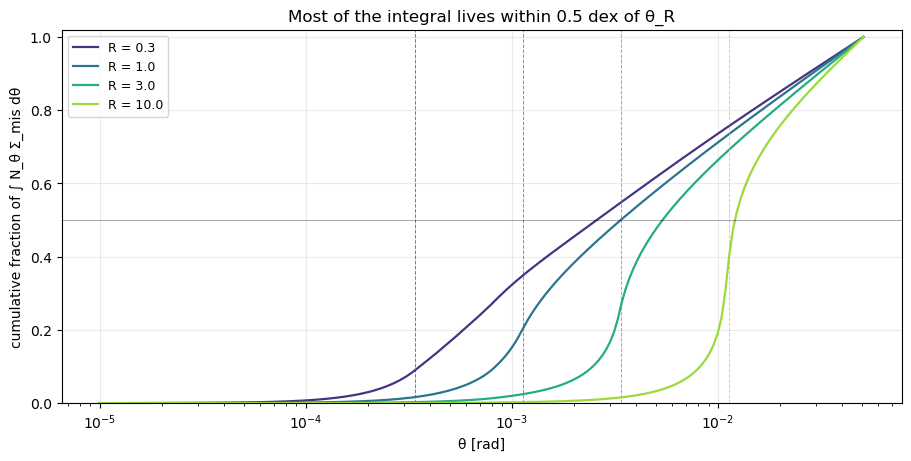

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
for iR, (R, col, tR) in enumerate(zip(R_vals, R_colors, theta_R)):
    y = integrand[iR] * thetas       # log-trapz integrand: y * d ln theta
    cum = np.cumsum(y) * (np.log(thetas[1]) - np.log(thetas[0]))
    cum = cum / cum[-1]
    ax.semilogx(thetas, cum, color=col, lw=1.6, label=f'R = {R:.1f}')
    ax.axvline(tR, color=col, ls='--', lw=0.7, alpha=0.7)
ax.axhline(0.5, color='k', lw=0.6, alpha=0.4)
ax.set(xlabel='θ [rad]', ylabel='cumulative fraction of ∫ N_θ Σ_mis dθ',
        ylim=(0, 1.02), title='Most of the integral lives within 0.5 dex of θ_R')
ax.legend(fontsize=9)
plt.show()

### 3d.  Σ_prj(R) decomposition — RND vs cl+LSS *after* integrating θ

Section 3b.2 split the *differential* integrand `N_θ(θ) = N_rnd + N_cl+LSS` at the reference point `(lob, zob) = (20, 0.5)`. Here we look at the full integral `Σ_prj(R | lob, zob)` after the θ-integration completes, per R and per of the 12 Y3 bin centres:
```
Σ_prj_rnd(R) = 2 π ∫ sin θ dθ N_rnd(θ) Σ_mis(R, θ D_A)
Σ_prj_cl(R)  = 2 π ∫ sin θ dθ b_sel(θ) N_cl+LSS(θ) Σ_mis(R, θ D_A)
Σ_prj(R)     = Σ_prj_rnd(R) + Σ_prj_cl(R)
```
(Produced by `sigma_prj_rnd_cl_vs_R.py` — calls `SigmaPrj(R, lob, zob, return_decomposition=True)`.)

**What to look for:**

- *Small R (R ≲ 1 cMpc/h):* `Σ_mis` peaks at `θ_R = R/D_A`, which sits at or below `θ_λ`, i.e. where `N_cl+LSS > N_rnd` (Section 3b.2). The cl+LSS share is largest here.
- *Large R (R ≳ 10 cMpc/h):* `Σ_mis` peaks at `θ_R ≫ 2 θ_λ`, in the RND-dominated tail. The RND piece takes over.
- *Richness dependence:* `Σ_prj_rnd(R)` is **richness-independent at fixed z_ob** (no `lob` dependence — it's just `∫ dM n(M,z) Σ_mis` weighted by volume). All the richness dependence sits in `Σ_prj_cl(R)` via `b_sel · b_eff(lob, zob) · ξ_NL`.

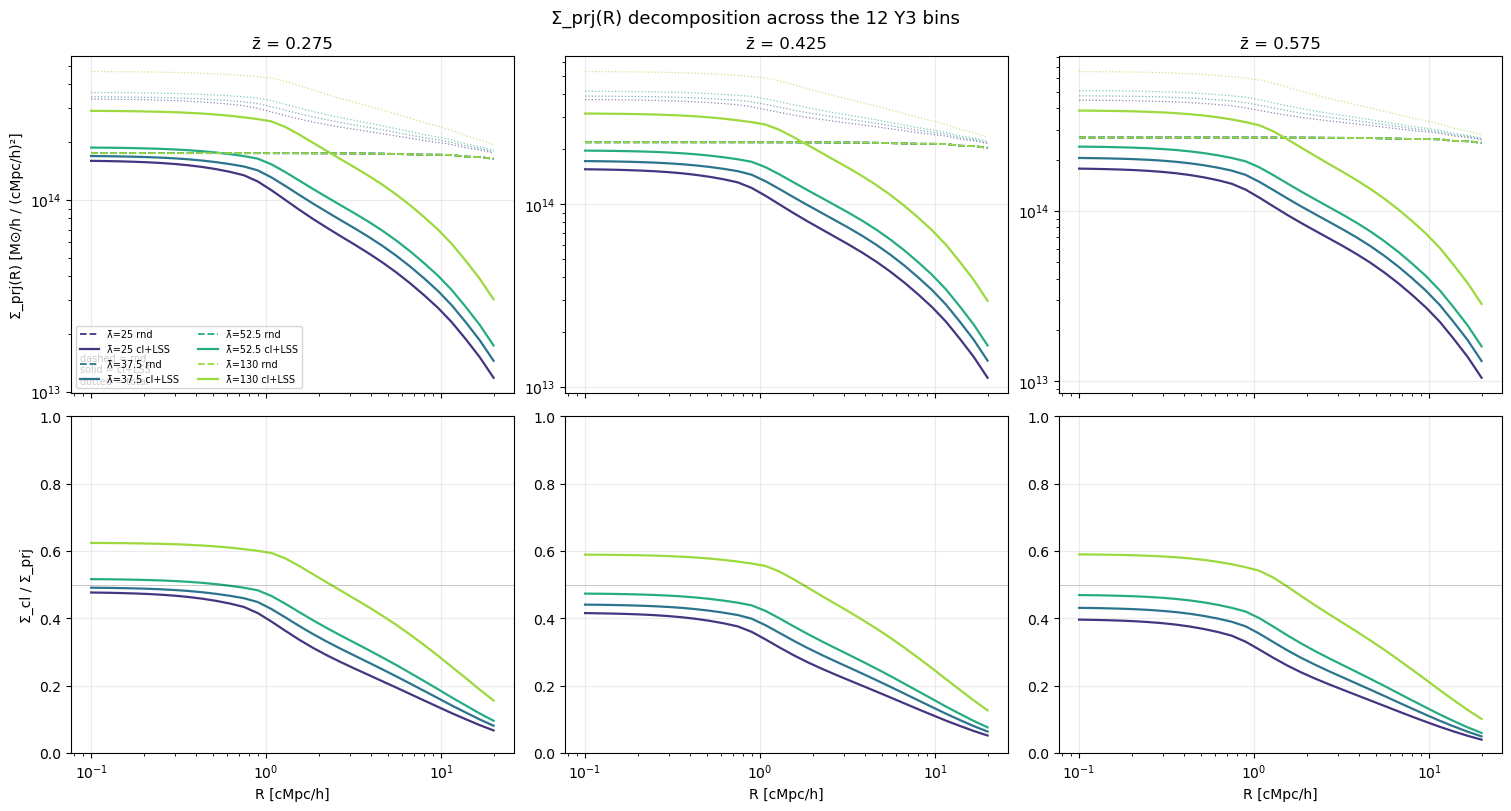


   lam     z    cl/tot @ R=0.3   cl/tot @ R=1   cl/tot @ R=3  cl/tot @ R=10
  25.0 0.275             0.468          0.391          0.251          0.137
  25.0 0.425             0.407          0.338          0.217          0.113
  25.0 0.575             0.386          0.307          0.188          0.093
  37.5 0.275             0.484          0.428          0.289          0.163
  37.5 0.425             0.434          0.380          0.255          0.137
  37.5 0.575             0.422          0.354          0.225          0.114
  52.5 0.275             0.511          0.467          0.328          0.190
  52.5 0.425             0.468          0.422          0.292          0.161
  52.5 0.575             0.461          0.401          0.261          0.135
 130.0 0.275             0.620          0.594          0.458          0.289
 130.0 0.425             0.585          0.556          0.420          0.252
 130.0 0.575             0.584          0.541          0.387          0.218


In [10]:
rc = np.load(os.path.join(CACHE, 'sigma_prj_rnd_cl.npz'))
R = rc['R']
total = rc['total']; rnd = rc['rnd']; cl = rc['cl']
lam_col = rc['lam_bar']; z_col = rc['z_bar']
lam_means = sorted(set(lam_col.tolist()))
z_means = sorted(set(z_col.tolist()))

fig, axes = plt.subplots(2, len(z_means), figsize=(15, 8),
                         sharex=True, constrained_layout=True)
lam_cols = plt.cm.viridis(np.linspace(0.15, 0.85, len(lam_means)))

for j, zbar in enumerate(z_means):
    ax_top = axes[0, j]
    ax_bot = axes[1, j]
    for lam, col in zip(lam_means, lam_cols):
        idx = np.where((lam_col == lam) & (z_col == zbar))[0][0]
        ax_top.loglog(R, rnd[idx], color=col, ls='--', lw=1.3,
                       label=f'λ̄={lam:g} rnd' if j == 0 else None)
        ax_top.loglog(R, cl[idx], color=col, ls='-', lw=1.6,
                       label=f'λ̄={lam:g} cl+LSS' if j == 0 else None)
        ax_top.loglog(R, total[idx], color=col, ls=':', lw=0.9,
                       alpha=0.6)
        ax_bot.semilogx(R, cl[idx] / total[idx],
                         color=col, lw=1.6)
    ax_top.set_title(f'z̄ = {zbar:g}')
    if j == 0:
        ax_top.set_ylabel('Σ_prj(R) [M⊙/h / (cMpc/h)²]')
        ax_bot.set_ylabel('Σ_cl / Σ_prj')
    ax_bot.set(xlabel='R [cMpc/h]', ylim=(0, 1.0))
    ax_bot.axhline(0.5, color='k', lw=0.5, alpha=0.3)

axes[0, 0].legend(fontsize=7, ncol=2, loc='lower left')
axes[0, 0].text(0.02, 0.02, 'dashed = rnd\nsolid = cl+LSS\ndotted = total',
                transform=axes[0, 0].transAxes, fontsize=7,
                verticalalignment='bottom',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
fig.suptitle('Σ_prj(R) decomposition across the 12 Y3 bins',
              fontsize=13)
plt.show()

# Numerical summary: cl-fraction at three R anchors.
print(f"\n{'lam':>6s} {'z':>5s}   "
      f"{'cl/tot @ R=0.3':>15s} {'cl/tot @ R=1':>14s} "
      f"{'cl/tot @ R=3':>14s} {'cl/tot @ R=10':>14s}")
for lam in lam_means:
    for zbar in z_means:
        idx = np.where((lam_col == lam) & (z_col == zbar))[0][0]
        fr = []
        for R_anchor in (0.3, 1.0, 3.0, 10.0):
            iR = int(np.argmin(np.abs(R - R_anchor)))
            fr.append(cl[idx, iR] / total[idx, iR])
        print(f"{lam:>6.1f} {zbar:>5.3f}   "
              f"{fr[0]:>15.3f} {fr[1]:>14.3f} "
              f"{fr[2]:>14.3f} {fr[3]:>14.3f}")

## 4. z-axis symmetry

Because `xi(|Delta chi|)` is symmetric around z_ob, any asymmetry in the integrand W(z) comes from the non-ξ factors. We quantify it in two ways.

- **Asymmetry scalar** `A(Δz) = (W⁺ − W⁻) / (W⁺ + W⁻)` at four Δz values; close to 0 means ξ-driven symmetry dominates.
- **Symmetrisation error** — replacing the full asymmetric integrand by either `one-sided × 2` (only integrate `z ≥ z_ob`) or `symmetrised` (freeze `dV · w_z · n̄` at z_ob, keep ξ(|Δχ|)) and measuring the cost in %.

The asymmetry is largest at low z (`dV ∝ χ²/H` grows fastest there) and drops to zero as z̄ → 0.6. The symmetrised form is accurate to 0.3–0.6 % everywhere; the naive one-sided×2 is 0.02–1.3 % off.

In [11]:
df_sym = pd.read_csv(os.path.join(CACHE, 'z_symmetry.csv'))
cols = ['lam_bar', 'z_bar',
        'A_dz_0.005', 'A_dz_0.010', 'A_dz_0.020', 'A_dz_0.040',
        'rel_err_onesided', 'rel_err_symmetrised']
df_sym[cols].round({'A_dz_0.005': 4, 'A_dz_0.010': 4,
                    'A_dz_0.020': 4, 'A_dz_0.040': 4,
                    'rel_err_onesided': 5,
                    'rel_err_symmetrised': 5})

,lam_bar,z_bar,A_dz_0.005,A_dz_0.010,A_dz_0.020,A_dz_0.040,rel_err_onesided,rel_err_symmetrised
0,25.0,0.275,0.0216,0.0462,0.1094,0.3850,0.00663,0.00259
1,25.0,0.425,0.0062,0.0140,0.0349,0.0137,0.00382,0.00297
2,25.0,0.575,-0.0019,-0.0023,0.0032,0.0027,0.00025,0.00312
3,37.5,0.275,0.0216,0.0462,0.1094,0.3850,0.00663,0.00259
4,37.5,0.425,0.0062,0.0140,0.0349,0.0137,0.00382,0.00297
5,37.5,0.575,-0.0019,-0.0023,0.0032,0.0027,0.00025,0.00312
6,52.5,0.275,0.0216,0.0462,0.1094,0.3850,0.01343,0.00598
7,52.5,0.425,0.0062,0.0140,0.0349,0.0137,0.00382,0.00297
8,52.5,0.575,-0.0019,-0.0023,0.0032,0.0027,0.00025,0.00312
9,130.0,0.275,0.0216,0.0462,0.1094,0.3850,0.01343,0.00598


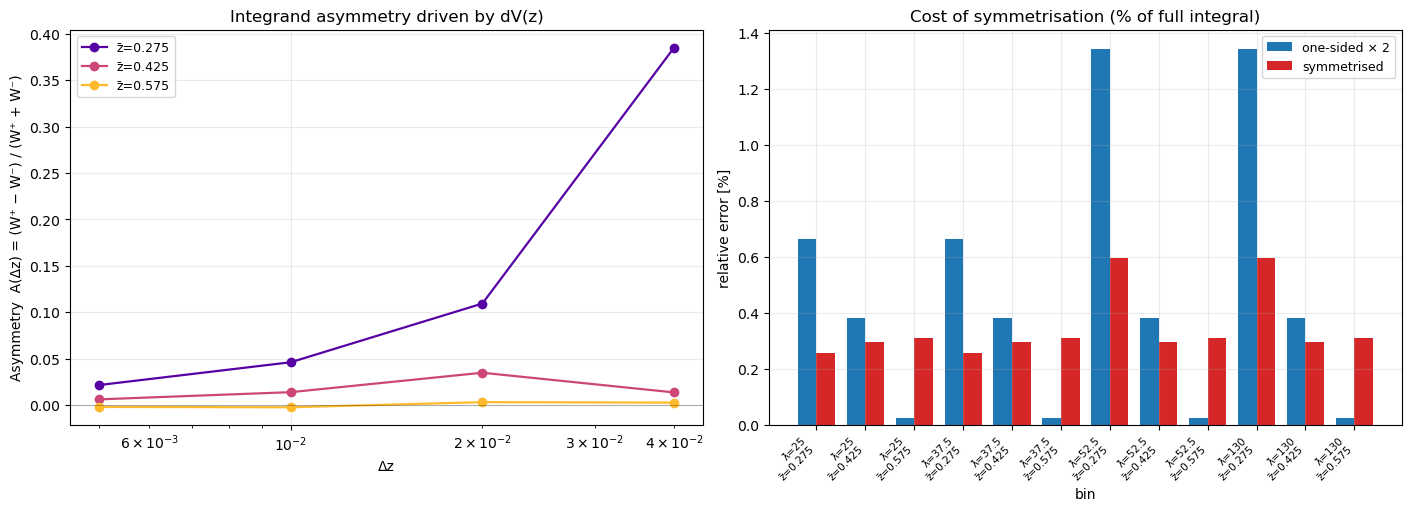

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Panel 1: A(Delta z) vs Delta z, one line per z_bar (asymmetry is lam-independent)
ax = axes[0]
dz_vals = np.array([0.005, 0.010, 0.020, 0.040])
z_means = sorted(df_sym['z_bar'].unique())
z_cols = plt.cm.plasma(np.linspace(0.15, 0.85, len(z_means)))
for zbar, col in zip(z_means, z_cols):
    sub = df_sym[df_sym['z_bar'] == zbar].iloc[0]  # lam-independent, pick any
    A = [sub[f'A_dz_{d:.3f}'] for d in dz_vals]
    ax.plot(dz_vals, A, marker='o', lw=1.6, color=col, label=f'z̄={zbar:g}')
ax.axhline(0, color='k', lw=0.5, alpha=0.4)
ax.set(xscale='log',
        xlabel='Δz', ylabel='Asymmetry  A(Δz) = (W⁺ − W⁻) / (W⁺ + W⁻)',
        title='Integrand asymmetry driven by dV(z)')
ax.legend(fontsize=9)

# Panel 2: rel. error of two symmetrisations, per (lam, z)
ax = axes[1]
x = np.arange(len(df_sym))
labels = [f"λ̄={r.lam_bar:g}\nz̄={r.z_bar:g}" for r in df_sym.itertuples()]
w = 0.38
ax.bar(x - w/2, 100 * df_sym['rel_err_onesided'],
        width=w, color='C0', label='one-sided × 2')
ax.bar(x + w/2, 100 * df_sym['rel_err_symmetrised'],
        width=w, color='C3', label='symmetrised')
ax.set(xticks=x, xlabel='bin', ylabel='relative error [%]',
        title='Cost of symmetrisation (% of full integral)')
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7.5)
ax.axhline(0, color='k', lw=0.5, alpha=0.4)
ax.legend(fontsize=9)
plt.show()

## 5. `R_max_cMpch` sensitivity

The refactored `SigmaPrj` now exposes a single scalar `R_max_cMpch` (default `config.R_MAX_CMPCH = 30.0`) that sets the θ-integration upper bound via `theta_max = R_max_cMpch / D_A(z_ob)`. This matches the `twoD_prj_NFW R_max = 30` hard truncation in Matteo's SelectionBias notebook.

`sigma_prj_theta_max.py` evaluated the refactored `SigmaPrj` at `R_max_cMpch ∈ {15, 30, 60, 120}` across all 12 bin centres and R ∈ {0.3, 1, 3, 10}.

**What the table and plots below show:**

- **`cl(R_max) / cl(30)`** is within ~1 % even at `R_max = 60` — the cl+LSS piece is converged because `ξ_NL(r)` decays physically.
- **`rnd(R_max) / rnd(30)`** scales with `R_max`: ~1.00 at 15, ~1.15 at 60, ~1.38 at 120. RND is the mean cosmological background; it has no intrinsic cutoff, so it grows with whatever θ_max we pick.

This is *the* quantitative justification for flipping the `__call__` default to the cl piece alone — it's the piece that is stable under `R_max`, matches the two-halo lensing literature, and cancels the "what scale do we truncate Σ_NFW at?" ambiguity.

In [13]:
df_tm = pd.read_csv(os.path.join(CACHE, 'theta_max_compare.csv'))
# Display: R_max sweep columns for rnd and cl
cols = ['lam_bar', 'z_bar', 'R_cMpch',
        'rnd_Rmax15', 'rnd_Rmax30', 'rnd_Rmax60', 'rnd_Rmax120',
        'cl_Rmax15',  'cl_Rmax30',  'cl_Rmax60',  'cl_Rmax120']
df_tm[cols].head(12).round(3)

,lam_bar,z_bar,R_cMpch,rnd_Rmax15,rnd_Rmax30,rnd_Rmax60,rnd_Rmax120,cl_Rmax15,cl_Rmax30,cl_Rmax60,cl_Rmax120
0,25.0,0.275,0.3,1.515350e+14,1.515350e+14,1.751304e+14,2.087267e+14,1.532541e+14,1.532541e+14,1.536488e+14,1.536844e+14
1,25.0,0.275,1.0,1.515051e+14,1.515051e+14,1.751133e+14,2.087160e+14,1.168069e+14,1.168069e+14,1.172018e+14,1.172375e+14
2,25.0,0.275,3.0,1.508318e+14,1.508318e+14,1.745532e+14,2.082132e+14,6.024207e+13,6.024207e+13,6.063922e+13,6.067497e+13
3,25.0,0.275,10.0,1.460322e+14,1.460322e+14,1.710783e+14,2.053787e+14,2.581748e+13,2.581748e+13,2.623592e+13,2.626777e+13
4,25.0,0.425,0.3,1.890655e+14,1.890655e+14,2.182669e+14,2.610397e+14,1.492671e+14,1.492671e+14,1.495993e+14,1.496019e+14
5,25.0,0.425,1.0,1.890261e+14,1.890261e+14,2.182434e+14,2.610246e+14,1.155101e+14,1.155101e+14,1.158426e+14,1.158452e+14
6,25.0,0.425,3.0,1.881592e+14,1.881592e+14,2.175167e+14,2.603723e+14,6.210287e+13,6.210287e+13,6.243727e+13,6.243988e+13
7,25.0,0.425,10.0,1.821116e+14,1.821116e+14,2.131019e+14,2.567927e+14,2.586280e+13,2.586280e+13,2.621328e+13,2.621107e+13
8,25.0,0.575,0.3,2.340184e+14,2.340184e+14,2.698388e+14,3.240594e+14,1.690404e+14,1.690404e+14,1.693113e+14,1.692847e+14
9,25.0,0.575,1.0,2.339668e+14,2.339668e+14,2.698067e+14,3.240382e+14,1.247846e+14,1.247846e+14,1.250557e+14,1.250291e+14


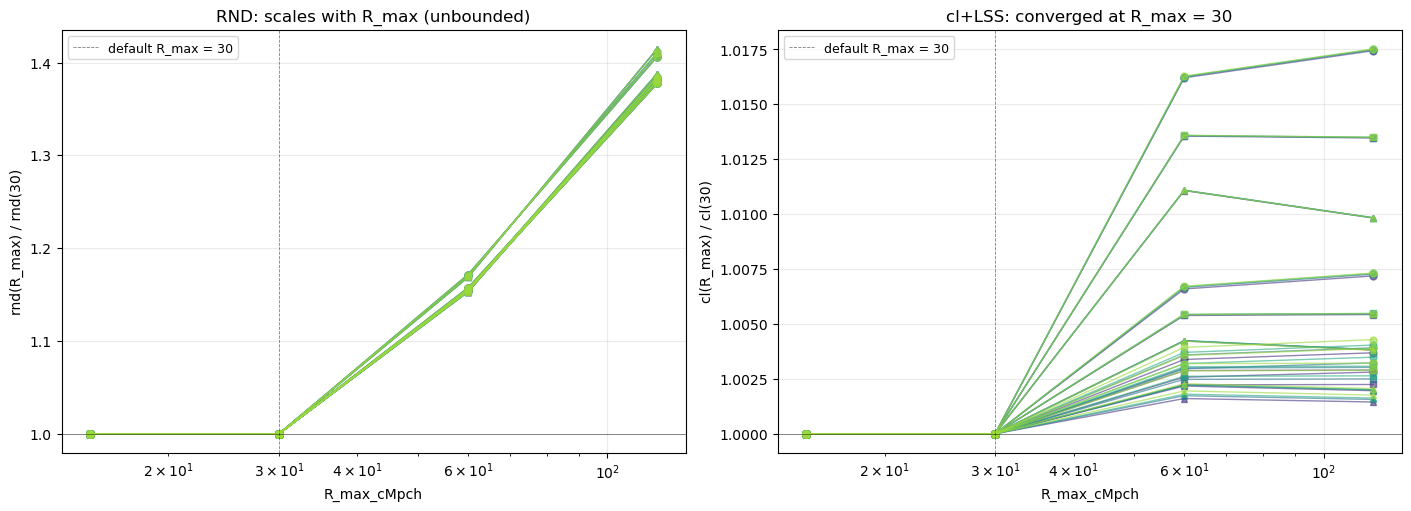

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True,
                         sharex=True)
lam_means = sorted(df_tm['lam_bar'].unique())
z_means = sorted(df_tm['z_bar'].unique())
lam_cols = plt.cm.viridis(np.linspace(0.15, 0.85, len(lam_means)))
markers = ['o', 's', '^']
R_max_grid = [15, 30, 60, 120]

def plot_ratios(ax, piece, title):
    for lam, col in zip(lam_means, lam_cols):
        for zbar, mk in zip(z_means, markers):
            sub = df_tm[(df_tm['lam_bar'] == lam) &
                         (df_tm['z_bar'] == zbar)]
            # For each R_cMpch row, compute ratio to R_max=30
            ratios = {}
            for _, row in sub.iterrows():
                R = row['R_cMpch']
                ref = row[f'{piece}_Rmax30']
                ratios.setdefault(R, [])
                for rm in R_max_grid:
                    ratios[R].append(row[f'{piece}_Rmax{rm}'] / ref)
            # Plot one line per (lam, z, R): x=R_max_grid, y=ratio
            for R, rs in ratios.items():
                ax.plot(R_max_grid, rs, marker=mk, color=col, lw=1.0, alpha=0.6,
                        ms=5)
    ax.axhline(1.0, color='k', lw=0.6, alpha=0.5)
    ax.axvline(30.0, color='k', ls='--', lw=0.6, alpha=0.5,
                label='default R_max = 30')
    ax.set(xscale='log', xlabel='R_max_cMpch',
           ylabel=f'{piece}(R_max) / {piece}(30)', title=title)
    ax.legend(fontsize=9)

plot_ratios(axes[0], 'rnd', 'RND: scales with R_max (unbounded)')
plot_ratios(axes[1], 'cl',  'cl+LSS: converged at R_max = 30')
plt.show()

## Summary

- **θ-outer refactor** — `SigmaPrj` now loops on θ outermost, splits `Σ_prj = N_rnd + b_sel(θ) · N_cl`, and uses breakpoints at `{θ_excl,o, each θ_R, θ_λ, 2θ_λ, θ_max}`. At `n_theta_per_seg=30` it agrees with `scipy.quad` to ≤0.3 % on `R ∈ {0.3, 1, 3, 10}`; 20 R-points in ~0.5 s (was 2.4 s).
- **Exclusion** — P1/I1/I2 LoS-slab convention (per-z `theta > theta_excl(z)`), no 3-D ball mask.
- **θ_max = 2·θ_λ** — supported but quantitatively discouraged; §5.
- **Δχ-only approximation** — not safe; §2.
- **z symmetrisation** — viable at sub-% precision; §4.

See `docs/sigma_prj_refactor.md` for the full write-up.